# Capacità

Questo notebook presenta una esercitazione finalizzata a comprendere e studiare come funziona l'adattamento di modelli di regressione. In particolare lo scopo ultimo è quello di confrontare diversi modelli di regressione polinomiale del tipo:
$$y = \beta_0+ \beta_1x+ \dots + \beta_p x^p + \epsilon$$
L'esercizio finale prevede di far variare il grado del polinomio $p$, effettuando per ciascun grado 20 run di addestramento. Si vuole inoltre che per ogni run si ripeta la procedura di splitting ex-novo; infine si dovrà creare un grafico che mostrerà l'andamento di $\text{MSE}_{train}$ ed $\text{MSE}_{test}$ al variare del grado del polinomio, per osservare quale sia la **capacità ottima del modello**. 

In questo contesto la capacità di un modello indica la sua *abilità di adattarsi a funzioni più o meno complesse*. La capacità è direttamente controllata dal grado del polinomio, perché al crescere di $p$ il modello diventa più flessibile, ma può anche rischiare l'**overfitting**. 

Quindi la capacità ottima è quel valore di $p$ che bilancia meglio questi due estremi ed è osservabile graficamente nel punto in cui $\text{MSE}_{test}$ è minimo, cioé quando il modello generalizza meglio su dati nuovi.

Questo concetto è strettamente legato al **trade-off tra bias e varianza**, perché aumentare la capacità del modello significa ridurre il bias ma aumentare la varianza, o viceversa.

Si ricorda che in generale l'MSE corrisponde a:
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$$
Naturalmente se si usano i valori target del training set o del test set si hanno le due versioni dell'MSE sopra citate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dd = pd.read_csv('data/function_1000_25.csv')
dd

,X,y
0,1.872701,2.783879
1,4.753572,-2.698304
2,3.659970,-1.690942
3,2.993292,-0.404486
4,0.780093,0.497187
...,...,...
995,0.457910,0.184149
996,4.586568,-3.267441
997,0.684093,0.563941
998,4.751187,-2.698495


## 01. Analisi Esplorativa

In [3]:
dd.shape # 1000 osservazioni, 2 variabili (X, y)

(1000, 2)

In [4]:
dd.describe()

,X,y
count,1000.000000,1000.000000
mean,2.451283,-0.445433
std,1.460687,1.599497
min,0.023160,-5.166565
25%,1.179866,-1.811375
50%,2.484037,-0.187648
75%,3.721598,0.866719
max,4.998588,3.570495


In [5]:
dd.isna().mean() # Non ci sono NA

X    0.0
y    0.0
dtype: float64

<Axes: xlabel='X', ylabel='y'>

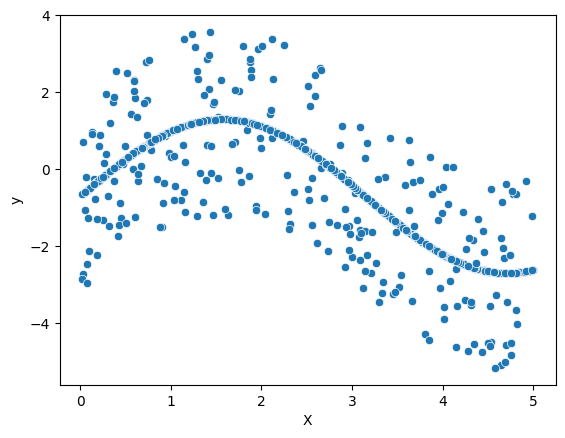

In [6]:
# Rappresentazione grafica scatterplot
sns.scatterplot(x='X', y='y', data = dd)

La rappresentazione rispecchia quanto descritto nel testo dell'esercitazione: i dati descrivono una sinusoide, ma parte di essi sono stati corrotti da rumore gaussiano. 

Prima di effettuare l'addestramento del modello è di fondamentale importanza rimuovere valori anomali, perché questi distorcono i coefficienti $\beta$, soprattutto al crescere del grado del polinomio, che ne aumenta l'instabilità. 

## Rimozione degli outlier

Viene chiesto di rimuovere gli outlier con il metodo Local Outlier Factor; prima di eseguirlo però, vediamo rapidamente in cosa consiste:

Il **Local Outlier Factor** (LOF) è un algoritmo di rilevamento degli outlier basato sulla *densità locale di ogni punto rispetto ai suoi vicini*: questa tecnica non individua quindi valori estremi in assoluto, ma relativi ai punti prossimi.  

LOF confronta la densità di un punto con la densità dei suoi vicini:
- Se un punto si trova in una zona molto meno densa rispetto ai suoi vicini $\rightarrow$ è un outlier;

In termini semplici, per ogni punto $x$, LOF calcola uno score che misura quanto la sua densità locale sia anomala rispetto a quella dei suoi $k$ vicini; se lo score è $\approx 1$ allora non si è davanti ad outlier, altrimenti  se lo score è  $>1$ quel punto è possibilmente un outlier.

Questo algoritmo va regolato principalmente usando due parametri che sono quelli relativi al numero di vicini $k$ che devono essere considerati per ciascun punto, facendo attenzione ad evitare $k$ troppo piccoli (sensibile a variazioni molto locali) o troppo alti (anomalie rispetto all'andamento globale, poco sensibile); l'altro parametro è quello relativo al **livello di contaminazione**, cioé la proporzione attesa di outlier nel dataset e serve a dire quanti punti ci si aspetta che siano outlier: in questo caso il 25%.

In [7]:
# Outlier detection con LOF (Local Outlier Factor)
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors = 32, contamination = 0.25)
dd['outlier'] = lof.fit_predict(dd[['X', 'y']])
dd['outlier'] = dd['outlier'].map({1: 'inlier', -1: 'outlier'})

<Axes: xlabel='X', ylabel='y'>

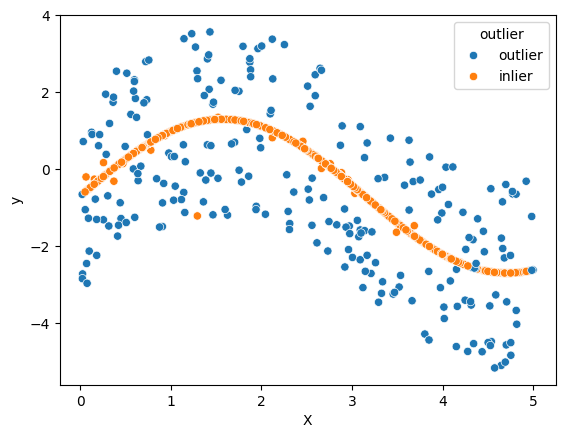

In [8]:
# Rappresentazione grafica con colorazione degli outlier
sns.scatterplot(x='X', y='y', hue = 'outlier', data = dd)

Si osserva chiaramente che i punti appartenenti alla sigmoide, con $k=32$, non vengono segnalati come outlier, mentre quelli a cui è stato applicato rumore gaussiano invece sì. Una buona regola euristica è quella di impostare $k \approx \sqrt{n}$, in questo caso quindi $\approx 32$.

Rimuoviamo dal dataset gli outlier individuati.

In [9]:
dd_clean = ( 
    dd[dd['outlier'] == 'inlier']
    .drop(columns = 'outlier')
    .copy()
)

## Outlier Analysis con Kernel Density

In [11]:
from sklearn.neighbors import KernelDensity

dd = dd.drop(columns = ['outlier'])

h = 0.5
kde = KernelDensity(bandwidth=h, kernel='gaussian').fit(dd)

kde_score = kde.score_samples(dd)
soglia = pd.Series(kde_score).quantile(q=0.2)

out = kde_score > soglia

In [19]:
len(out)

1000

In [13]:
dd_clean_kde = dd[out]

In [18]:
dd_clean_kde.shape

(800, 2)

In [14]:
dd_clean_kde.describe().round(2)

,X,y
count,800.00,800.00
mean,2.51,-0.38
std,1.42,1.41
min,0.07,-2.90
25%,1.25,-1.80
50%,2.53,0.04
75%,3.73,0.87
max,5.00,1.74


<Axes: xlabel='X', ylabel='y'>

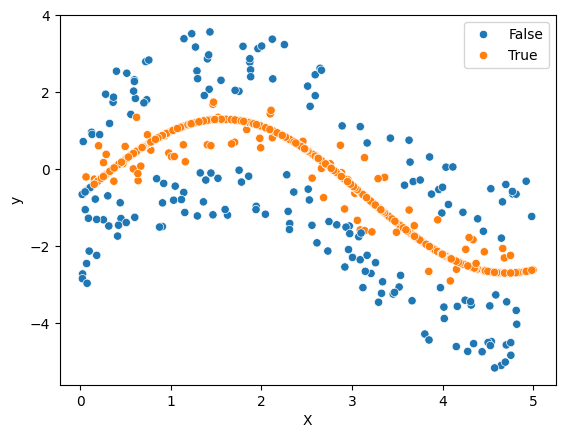

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data = dd, x='X', y = 'y', hue=out)

## Adattare un modello di regressione

Adesso abbiamo il dataset in cui abbiamo rimosso gli outlier con la LOF, quindi ora bisogna adattare un modello di regressione polinomiale valutando diversi valori possibili per il grado del polinomio e rispondere alla domanda: *qual è il grado polinomiale ottimo per questo dataset?*

Per rispondere a questa domanda bisogna **addestrare un modello per ogni grado e misurare la capacità di generalizzazione tramite MSE**.

In [ ]:
gradi = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Poiché l'esecuzione di un solo split in train/test è dipendente dal caso, **si ripete 20 volte lo split in modo indipendente** per ogni modello, calcolando poi media e deviazione standard del MSE. In questo modo si ottiene una stima robusta delle prestazioni del modello, non legate ad un singolo esperimento.

Organizzeremo il codice per effettuare questa stima attraverso una **Pipeline**, strumento che in scikit-learn consente di concatenare trasformazioni e modelli evitando il data leakage. 

Ogni run (20 per ciascun grado della lista), richiede le seguenti operazioni:

1. Split train/test (`train_test_split` from `sklearn.model_selection`)
2. Trasformazione polinomiale delle features (`PolynomialFeatures` from `sklearn.preprocessing`)
3. Adattamento del modello (`LinearRegression` from `sklearn.linear_model`)
4. Calcolo di MSE su training e test set (`mean_squared_error` from `sklearn.metrics`)

Implementeremo il tutto usando una pipeline:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

#set_config
from sklearn._config import set_config
set_config(transform_output='pandas')

In [ ]:
X = dd_clean[['X']]
y = dd_clean['y']

Lo scorrimento lungo la lista di possibili gradi e il calcolo degli MSE per ogni run è organizzata in due cicli for, che seguono la seguente struttura:

`per ogni grado p:`

    └── per ogni run (1..20):

            ├── split ex-novo train/test

            ├── fit della pipeline su train

            ├── calcolo MSE_train

            └── calcolo MSE_test
            
    └── calcola media e std di MSE_train e MSE_test sui 20 run

In questo modo il for esterno controlla la complessità del modello, mentre quello interno stima l'MSE.

In [ ]:
n_runs = 20
results = []

for p in gradi:
    mse_train = []
    mse_test = []

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree = p, include_bias = False)),
        ('linreg', LinearRegression())
    ])

    for _ in range(n_runs):
        # Splitting per ogni run (niente stratify perché non è un problema di classificazione, e nessun random_state per non fissare lo stesso splitting)
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.10)

        # Fit del modello
        pipeline.fit(X_tr, y_tr)

        # Calcolo MSE su train e test
        mse_train.append(mean_squared_error(y_tr, pipeline.predict(X_tr)))
        mse_test.append(mean_squared_error(y_te, pipeline.predict(X_te)))

    results.append({
        'grado': p,
        'mse_train_mean': np.mean(mse_train),
        'mse_train_std': np.std(mse_train),
        'mse_test_mean': np.mean(mse_test),
        'mse_test_std': np.std(mse_test)
    })

Qual è il vantaggio della pipeline? In questo caso, prima di addestrare il modello di regressione, i valori di X devono essere trasformati nei polinomi; la Pipeline quindi permette di eseguire in sequenza le operazioni:

- X_train $\rightarrow$ PolynomialFeatures(degree = p) $\rightarrow$ LinearRegression 

Il vantaggio è che la trasformazione polinomiale viene adattata solo sul training set e poi applicata al test set, evitando data leakage. 

**NB: in questa implementazione abbiamo creato tre liste numpy vuote con `results`, `mse_train` e `mse_test`, quando le dobbiamo riempire con i valori di media e deviazione standard, o con gli MSE calcolati, si userà il metodo `.append` degli oggetti NumPy**

## Rappresentazione grafica degli MSE al crescere di $p$

Se adesso rappresentiamo `mse_train_mean` e `mse_test_mean` al variare di `p`, troveremo il **grado ottimo** in corrispondenza del minimo di $\text{MSE}_{test}$.

In [ ]:
df_results = pd.DataFrame(results)

# La sintassi è .plot(x, y, marker = 'o', label = 'etichetta per legenda')
plt.plot(df_results['grado'], df_results['mse_train_mean'], marker='o', label='MSE Train')
plt.plot(df_results['grado'], df_results['mse_test_mean'],  marker='o', label='MSE Test')

# con fill_between possiamo aggiungere l'intervallo di confidenza
# la sintassi è plt.fill_between(x, y1, y2, alpha = 0.2)
plt.fill_between(df_results['grado'],
                 df_results['mse_train_mean'] - df_results['mse_train_std'],
                 df_results['mse_train_mean'] + df_results['mse_train_std'],
                 alpha = 0.2 #controlla l'opacità
                 )

plt.fill_between(df_results['grado'],
                 df_results['mse_test_mean'] - df_results['mse_test_std'],
                 df_results['mse_test_mean'] + df_results['mse_test_std'],
                 alpha = 0.2 #controlla l'opacità
                 )

plt.xlabel('Grado del polinomio')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [ ]:
df_results.loc[df_results['mse_test_mean'].idxmin()] # p = 4

La capacità ottima del modello si raggiunge quando $p = 4$, perché è il punto in cui l'MSE sul test set raggiunge il minimo. 

# Stima del modello: KernelRidge

In [22]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

In [23]:
kkr = KernelRidge(kernel="rbf")

param = {
    'alpha': [0.001, 0.1, 1],
    'gamma': [0.001, 0.01, 0.05]
}

In [24]:
gs = GridSearchCV(
    estimator=kkr,
    param_grid=param,
    scoring = 'r2',
    n_jobs = 3,
    cv = 5,
    verbose=3
)

In [25]:
gs.fit(dd_clean_kde[['X']], dd_clean_kde['y'])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 2/5] END ..........alpha=0.001, gamma=0.001;, score=0.880 total time=   0.1s[CV 3/5] END ..........alpha=0.001, gamma=0.001;, score=0.884 total time=   0.1s
[CV 1/5] END ..........alpha=0.001, gamma=0.001;, score=0.898 total time=   0.1s

[CV 4/5] END ..........alpha=0.001, gamma=0.001;, score=0.893 total time=   0.0s
[CV 5/5] END ..........alpha=0.001, gamma=0.001;, score=0.885 total time=   0.0s
[CV 1/5] END ...........alpha=0.001, gamma=0.01;, score=0.983 total time=   0.0s
[CV 3/5] END ...........alpha=0.001, gamma=0.01;, score=0.977 total time=   0.0s
[CV 2/5] END ...........alpha=0.001, gamma=0.01;, score=0.980 total time=   0.0s
[CV 4/5] END ...........alpha=0.001, gamma=0.01;, score=0.972 total time=   0.0s
[CV 1/5] END ...........alpha=0.001, gamma=0.05;, score=0.990 total time=   0.0s
[CV 5/5] END ...........alpha=0.001, gamma=0.01;, score=0.979 total time=   0.0s
[CV 2/5] END ...........alpha=0.001, gamma=0.05;,

GridSearchCV(cv=5, estimator=KernelRidge(kernel='rbf'), n_jobs=3,
             param_grid={'alpha': [0.001, 0.1, 1],
                         'gamma': [0.001, 0.01, 0.05]},
             scoring='r2', verbose=3)

In [26]:
gs.best_params_

{'alpha': 0.001, 'gamma': 0.05}

In [27]:
gs.best_score_ #R2

np.float64(0.9865142449703365)

Adesso generiamo **1000 valori casuali compresi tra il minimo e il massimo del dataset** da usare come test set.

In [28]:
low = dd_clean_kde[['X']].agg(func='min')
up = dd_clean_kde[['X']].agg(func = 'max')

X_test = np.random.uniform(low = low, high = up, size = 1000)
X_test = pd.DataFrame(X_test, columns = ['X'])
X_test 

,X
0,3.846222
1,3.577401
2,1.662233
3,2.028371
4,0.456757
...,...
995,0.747012
996,3.286372
997,1.544075
998,4.358655


In [29]:
y_pred = gs.predict(X_test)
y_pred = pd.Series(y_pred)

<Axes: xlabel='X', ylabel='None'>

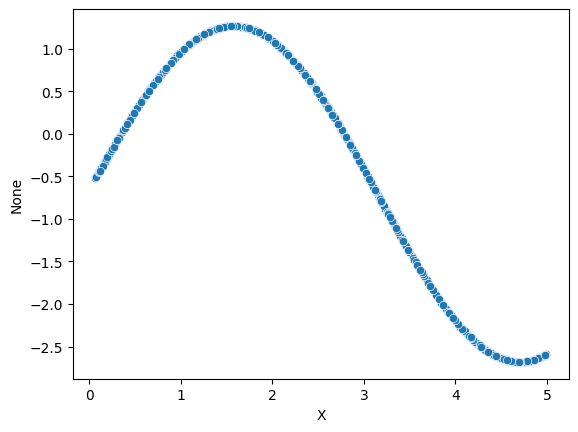

In [30]:
sns.scatterplot(data=X_test, x = 'X', y = y_pred)